In [1]:
import sys
import os
import matplotlib.pyplot as plt
import torch
# Add the src directory to the path. TEMPORARY FIX
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

print(sys.path)

from src.predictor import ShorelinePredictor

['/home/josep/miniforge3/envs/shoreline/lib/python313.zip', '/home/josep/miniforge3/envs/shoreline/lib/python3.13', '/home/josep/miniforge3/envs/shoreline/lib/python3.13/lib-dynload', '', '/home/josep/miniforge3/envs/shoreline/lib/python3.13/site-packages', '/home/josep/LOCALDATA/Shoreline-extraction']


In [2]:
from src.data_processing.dataset_loader import CoastData
from src.models.data_management.data_loader import DataLoaderManager

import cv2

In [3]:
# Execute this cell to make sure 
# that external modules are reloaded
%load_ext autoreload
%autoreload 2

In [4]:
model_weight_path = os.path.abspath(os.path.join(os.getcwd(), "../artifacts/", "2025-10-02-10-54-16_2_classes_256x1024_b24/models/best_model.pth"))

model = "DeepLabV3"
num_classes = 2

predictor = ShorelinePredictor(model, model_weight_path, num_classes)

In [5]:
data_path = os.path.abspath(os.path.join(os.getcwd(), "../data/processed_obliques_2_classes"))

coast_data = CoastData(data_path)
split = coast_data.split_data()

data = DataLoaderManager.load_data(split)

CoastData: global - 1717 images
Coast: agrelo, Total size: 244
Coast: arenaldentem, Total size: 40
Coast: cadiz, Total size: 946
Coast: cies, Total size: 430
Coast: samarador, Total size: 57


/home/josep/LOCALDATA/Shoreline-extraction/data/processed_obliques_2_classes/images/1525622460.Sun.May.06_17_01_00.CET.2018.cies.image.jpg


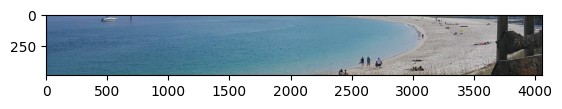

Image shape: (491, 4056, 3)
(1704, 2)
{'coordinates': {'u': [2174, 2163, 2164, 2165, 2166, 2167, 2168, 2169, 2170, 2171, 2172, 2173, 2157, 2158, 2159, 2160, 2161, 2162, 2163, 2164, 2165, 2166, 2167, 2168, 2169, 2170, 2171, 2172, 2173, 2174, 2175, 2176, 2177, 2178, 2179, 2180, 2181, 2182, 2183, 2184, 2185, 2186, 2187, 2188, 2189, 2190, 2191, 2192, 2193, 2194, 2195, 2196, 2197, 2198, 2199, 2200, 2201, 2202, 2203, 2204, 2205, 2206, 2207, 2208, 2209, 2210, 2211, 2212, 2213, 2214, 2215, 2216, 2217, 2218, 2219, 2220, 2221, 2222, 2223, 2224, 2225, 2226, 2227, 2228, 2229, 2230, 2231, 2232, 2233, 2234, 2235, 2236, 2237, 2238, 2239, 2240, 2241, 2242, 2243, 2244, 2245, 2246, 2247, 2248, 2249, 2250, 2251, 2252, 2253, 2254, 2255, 2256, 2257, 2258, 2259, 2260, 2261, 2262, 2263, 2264, 2265, 2266, 2267, 2268, 2269, 2270, 2271, 2272, 2273, 2274, 2275, 2276, 2277, 2278, 2279, 2280, 2281, 2282, 2283, 2284, 2285, 2286, 2287, 2288, 2289, 2290, 2291, 2292, 2293, 2294, 2295, 2296, 2297, 2298, 2299, 2300, 230

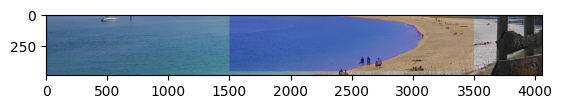

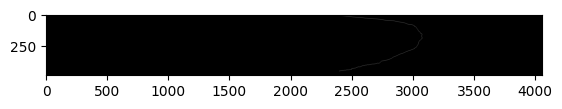

New image shape: (491, 4056, 3)
Shoreline coordinates: {'coordinates': {'u': [2174, 2163, 2164, 2165, 2166, 2167, 2168, 2169, 2170, 2171, 2172, 2173, 2157, 2158, 2159, 2160, 2161, 2162, 2163, 2164, 2165, 2166, 2167, 2168, 2169, 2170, 2171, 2172, 2173, 2174, 2175, 2176, 2177, 2178, 2179, 2180, 2181, 2182, 2183, 2184, 2185, 2186, 2187, 2188, 2189, 2190, 2191, 2192, 2193, 2194, 2195, 2196, 2197, 2198, 2199, 2200, 2201, 2202, 2203, 2204, 2205, 2206, 2207, 2208, 2209, 2210, 2211, 2212, 2213, 2214, 2215, 2216, 2217, 2218, 2219, 2220, 2221, 2222, 2223, 2224, 2225, 2226, 2227, 2228, 2229, 2230, 2231, 2232, 2233, 2234, 2235, 2236, 2237, 2238, 2239, 2240, 2241, 2242, 2243, 2244, 2245, 2246, 2247, 2248, 2249, 2250, 2251, 2252, 2253, 2254, 2255, 2256, 2257, 2258, 2259, 2260, 2261, 2262, 2263, 2264, 2265, 2266, 2267, 2268, 2269, 2270, 2271, 2272, 2273, 2274, 2275, 2276, 2277, 2278, 2279, 2280, 2281, 2282, 2283, 2284, 2285, 2286, 2287, 2288, 2289, 2290, 2291, 2292, 2293, 2294, 2295, 2296, 2297, 2298

In [23]:
index = 0
img_path = sorted(data["test"]['images'])[index]
print(img_path)

image = cv2.imread(img_path)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
# plt.axis('off')
plt.show()

print("Image shape:", image.shape)

crop = ((0,1500), (461,3500))  # ((y_min, y_max), (x_min, x_max))

output = predictor.predict_roi(img_path, crop_coords=crop, patch_size=(256, 1024), stride=(128, 512))

plt.imshow(output["predicted_image"])
plt.show()

plt.imshow(output["shoreline_mask"], cmap='gray')
plt.show()

print("New image shape:", output["predicted_image"].shape)
print("Shoreline coordinates:", output["shoreline_coords"])


# Prediction from SCLabels

In [24]:
data_path = os.path.abspath(os.path.join(os.getcwd(), "../data/SCLabels_v1.0.0"))

coast_data = CoastData(data_path, name="arenaldentem")
split = coast_data.split_data()

data = DataLoaderManager.load_data(split)

CoastData: arenaldentem - 40 images
Coast: arenaldentem, Total size: 40


In [25]:
model_weight_path = os.path.abspath(os.path.join(os.getcwd(), "../artifacts/", "2025-03-12-11-44-51_deeplab/models/best_model.pth"))

model = "DeepLabV3"
num_classes = 3

predictor = ShorelinePredictor(model, model_weight_path, num_classes)

/home/josep/LOCALDATA/Shoreline-extraction/data/SCLabels_v1.0.0/images/1668498240.Tue.Nov.15_08_44_00.CET.2022.arenaldentem.image.jpg


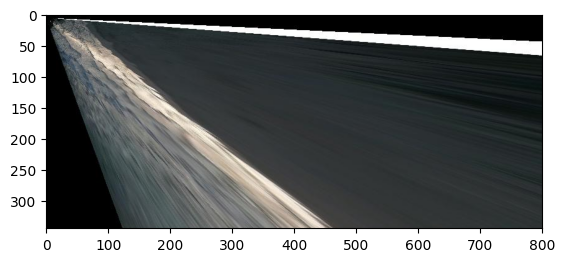

Image shape: (345, 801, 3)
((10, 7), (334, 800))


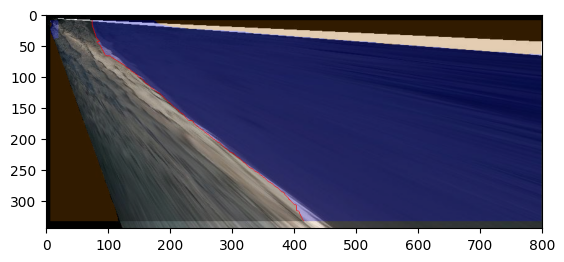

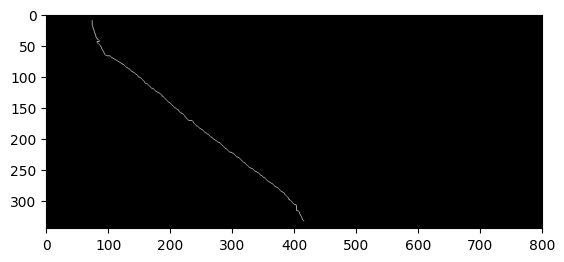

Shoreline coordinates: {'coordinates': {'u': [74, 74, 74, 74, 74, 74, 74, 74, 75, 75, 75, 75, 76, 76, 76, 77, 77, 77, 78, 78, 78, 79, 79, 79, 80, 80, 80, 81, 81, 82, 82, 83, 84, 85, 86, 82, 83, 84, 85, 82, 83, 84, 85, 86, 87, 88, 88, 89, 89, 89, 90, 91, 91, 92, 92, 93, 93, 94, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 214, 215, 216, 217, 218, 219, 220, 221, 222, 223, 224, 224, 225, 226, 227, 228, 229, 230, 231, 232, 233, 234

In [26]:
index = 3
img_path = sorted(data["test"]['images'])[index]
print(img_path)

image = cv2.imread(img_path)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
# plt.axis('off')
plt.show()

print("Image shape:", image.shape)

mask_path = sorted(data["test"]['masks'])[index]
output = predictor.predict_rectified_with_mask(img_path, mask_path=mask_path, patch_size=(256, 256), stride=(128, 128))

plt.imshow(output["predicted_image"])
plt.show()

plt.imshow(output["shoreline_mask"], cmap='gray')
plt.show()

# print("New image shape:", output["predicted_image"].shape)
print("Shoreline coordinates:", output["shoreline_coords"])